In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from src.utils.preprocessing import load_breast_cancer_data
from src.utils.bias_variance_helper import (
    run_bias_variance_experiment,
    plot_bias_variance,
)

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.30
B = 100
N_ESTIMATORS = 100

In [6]:
X_bc, y_bc, _ = load_breast_cancer_data(
    optimize_memory=False,
    verbose=False,
)

X = X_bc.to_numpy(dtype=np.float64)
y = y_bc.to_numpy().ravel().astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:")
print(pd.Series(y).value_counts(normalize=True).sort_index())

X shape: (569, 30)
y shape: (569,)
Class distribution:
0    0.372583
1    0.627417
Name: proportion, dtype: float64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train samples:", len(y_train))
print("Test samples:", len(y_test))

print("\nTrain class distribution:")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

print("\nTest class distribution:")
print(pd.Series(y_test).value_counts(normalize=True).sort_index())

Train samples: 398
Test samples: 171

Train class distribution:
0    0.371859
1    0.628141
Name: proportion, dtype: float64

Test class distribution:
0    0.374269
1    0.625731
Name: proportion, dtype: float64


In [8]:
bias_variance_results = run_bias_variance_experiment(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    n_bootstrap=B,
    n_estimators=N_ESTIMATORS,
    random_state=RANDOM_STATE,
    rf_n_jobs=-1,
)

Completed 10/100 replicates
Completed 20/100 replicates
Completed 30/100 replicates
Completed 40/100 replicates
Completed 50/100 replicates
Completed 60/100 replicates
Completed 70/100 replicates
Completed 80/100 replicates
Completed 90/100 replicates
Completed 100/100 replicates


In [9]:
display(
    bias_variance_results.style.format(
        {
            "bias_squared": "{:.6f}",
            "variance": "{:.6f}",
            "total_error": "{:.6f}",
            "mean_accuracy": "{:.4f}",
            "accuracy_std": "{:.4f}",
        }
    )
)

,model,bias_squared,variance,total_error,mean_accuracy,accuracy_std
0,AdaBoost,0.026048,0.018396,0.044444,0.9556,0.0097
1,Random Forest,0.046186,0.012294,0.058480,0.9415,0.0088


In [10]:
check_df = bias_variance_results[
    [
        "model",
        "bias_squared",
        "variance",
        "total_error",
    ]
].copy()

check_df["bias_plus_variance"] = (
    check_df["bias_squared"]
    + check_df["variance"]
)

check_df["difference"] = np.abs(
    check_df["total_error"]
    - check_df["bias_plus_variance"]
)

display(
    check_df.style.format(
        {
            "bias_squared": "{:.8f}",
            "variance": "{:.8f}",
            "total_error": "{:.8f}",
            "bias_plus_variance": "{:.8f}",
            "difference": "{:.10f}",
        }
    )
)

,model,bias_squared,variance,total_error,bias_plus_variance,difference
0,AdaBoost,0.02604795,0.01839649,0.04444444,0.04444444,0.0000000000
1,Random Forest,0.04618596,0.01229357,0.05847953,0.05847953,0.0000000000


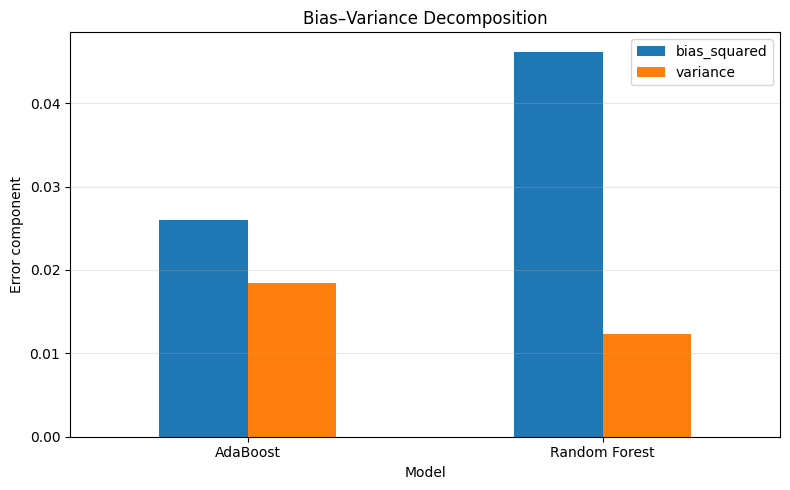

In [11]:
plot_bias_variance(
    bias_variance_results
)

In [12]:
for _, row in bias_variance_results.iterrows():
    print(f"\n{row['model']}")
    print(f"Bias²: {row['bias_squared']:.6f}")
    print(f"Variance: {row['variance']:.6f}")
    print(f"Total error: {row['total_error']:.6f}")
    print(f"Mean accuracy: {row['mean_accuracy']:.4f}")
    print(f"Accuracy std: {row['accuracy_std']:.4f}")


AdaBoost
Bias²: 0.026048
Variance: 0.018396
Total error: 0.044444
Mean accuracy: 0.9556
Accuracy std: 0.0097

Random Forest
Bias²: 0.046186
Variance: 0.012294
Total error: 0.058480
Mean accuracy: 0.9415
Accuracy std: 0.0088


## Final Bias–Variance Conclusion

The experiment clearly confirms the expected roles of boosting and bagging. AdaBoost achieved a lower bias² of **0.0260** compared with **0.0462** for Random Forest, showing that boosting produced predictions that were closer to the true labels on average. Random Forest, however, achieved a lower variance of **0.0123** compared with **0.0184** for AdaBoost, demonstrating greater stability across the 100 bootstrap samples.

Overall, AdaBoost delivered the lower total error (**0.0444**) and higher mean accuracy (**95.56%**), while Random Forest was slightly more stable. These results strongly support the conclusion that **boosting primarily reduces bias, whereas bagging primarily reduces variance**.
